In [2]:
import requests
from bs4 import BeautifulSoup
import csv
import pandas as pd
import matplotlib.pyplot as plt
import time

In [3]:
url = "https://www.worldometers.info/world-population/population-by-country/"
#header to pretend like a real browser (prevents blocking)
headers = {"User-Agent": "Mozilla/5.0"}
#sending request to the website
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")
#choosing the main main data table
tables = soup.find_all("table")
print("Total tables found:", len(tables))
table = max(tables, key=lambda t: len(t.find_all("tr")))
#to get all rows inside table
rows = table.find_all("tr")
data = []


Total tables found: 1


In [4]:
#skipping the header row over here
for row in rows[1:]:
    cols = row.find_all("td")
    if len(cols) > 6:
        data.append([
            cols[1].text.strip(),
            cols[2].text.strip(),
            cols[3].text.strip(),
            cols[4].text.strip(),
            cols[5].text.strip(),
            cols[6].text.strip()
        ])
    time.sleep(1)  #to pause for 1 second between requests to avoid overloading server of the website
for row in data:
    print(row)

['India', '1,476,625,576', '0.87%', '12,760,051', '497', '2,973,190']
['China', '1,412,914,089', 'â\x88\x920.22%', 'â\x88\x923,182,005', '150', '9,388,211']
['United States', '349,035,494', '0.51%', '1,759,687', '38', '9,147,420']
['Indonesia', '287,886,782', '0.76%', '2,165,546', '159', '1,811,570']
['Pakistan', '259,299,791', '1.6%', '4,080,237', '336', '770,880']
['Nigeria', '242,431,832', '2.06%', '4,904,050', '266', '910,770']
['Brazil', '213,562,666', '0.35%', '750,261', '26', '8,358,140']
['Bangladesh', '177,818,044', '1.21%', '2,131,145', '1,366', '130,170']
['Russia', '143,394,458', 'â\x88\x920.42%', 'â\x88\x92602,935', '9', '16,376,870']
['Ethiopia', '138,902,185', '2.53%', '3,430,134', '139', '1,000,000']
['Mexico', '132,997,658', '0.8%', '1,050,758', '68', '1,943,950']
['Japan', '122,427,731', 'â\x88\x920.55%', 'â\x88\x92675,748', '336', '364,555']
['Egypt', '120,101,175', '1.47%', '1,735,180', '121', '995,450']
['Philippines', '117,724,471', '0.8%', '937,509', '395', '298,

In [5]:
print(len(data))

234


In [6]:
tables = soup.find_all("table")
print("Tables found:", len(tables))
table = max(tables, key=lambda t: len(t.find_all("tr")))
rows = table.find_all("tr")
#Printing total rows found including the header row hence 235 rows showing
print("Rows found:", len(rows))

Tables found: 1
Rows found: 235


In [7]:
for item in data[:5]:
    print("Country Record With COLUMN Names")
    print("Country:", item[0])
    print("Population:", item[1])
    print("Yearly Change:", item[2])
    print("Net Change:", item[3])
    print("Density:", item[4])
    print("World Share:", item[5])

Country Record With COLUMN Names
Country: India
Population: 1,476,625,576
Yearly Change: 0.87%
Net Change: 12,760,051
Density: 497
World Share: 2,973,190
Country Record With COLUMN Names
Country: China
Population: 1,412,914,089
Yearly Change: â0.22%
Net Change: â3,182,005
Density: 150
World Share: 9,388,211
Country Record With COLUMN Names
Country: United States
Population: 349,035,494
Yearly Change: 0.51%
Net Change: 1,759,687
Density: 38
World Share: 9,147,420
Country Record With COLUMN Names
Country: Indonesia
Population: 287,886,782
Yearly Change: 0.76%
Net Change: 2,165,546
Density: 159
World Share: 1,811,570
Country Record With COLUMN Names
Country: Pakistan
Population: 259,299,791
Yearly Change: 1.6%
Net Change: 4,080,237
Density: 336
World Share: 770,880


In [8]:
#saving CSV
with open("population_data.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Country","Population","Yearly Change","Net Change","Density","World Share"])
    writer.writerows(data)

In [9]:
#Loading Data
df = pd.read_csv("population_data.csv")
df = df.replace("â", "-", regex=True) #to fix encoding issue
df

,Country,Population,Yearly Change,Net Change,Density,World Share
0,India,"1,476,625,576",0.87%,"12,760,051",497,"2,973,190"
1,China,"1,412,914,089",-0.22%,"-3,182,005",150,"9,388,211"
2,United States,"349,035,494",0.51%,"1,759,687",38,"9,147,420"
3,Indonesia,"287,886,782",0.76%,"2,165,546",159,"1,811,570"
4,Pakistan,"259,299,791",1.6%,"4,080,237",336,"770,880"
...,...,...,...,...,...,...
229,Montserrat,"4,328",-0.71%,-31,43,100
230,Falkland Islands,"3,465",-0.12%,-4,0,"12,170"
231,Tokelau,"2,691",3.18%,83,269,10
232,Niue,"1,822",0.05%,1,7,260


In [22]:
print(df["Population"].dtype)

int64


In [10]:
#Analysis : Sorting the dataset in descending order that is largest to smallest population which helps us see the most populated countries at the top
df_sorted = df.sort_values("Population", ascending=False)
df_sorted.head(10)

,Country,Population,Yearly Change,Net Change,Density,World Share
197,St. Vincent & Grenadines,"99,245",-0.68%,-679,254,390
198,Antigua and Barbuda,"94,626",0.44%,417,215,440
160,Fiji,"937,282",0.44%,"4,128",51,"18,270"
16,Iran,"93,168,497",0.81%,"750,816",57,"1,628,550"
94,Togo,"9,930,918",2.15%,"209,310",183,"54,390"
95,Greece,"9,897,115",-0.42%,"-41,729",77,"128,900"
96,Israel,"9,647,689",1.37%,"130,508",446,"21,640"
97,Hungary,"9,585,818",-0.48%,"-46,469",106,"90,530"
226,Tuvalu,"9,362",-1.37%,-130,312,30
98,Austria,"9,107,266",-0.07%,"-6,308",111,"82,409"


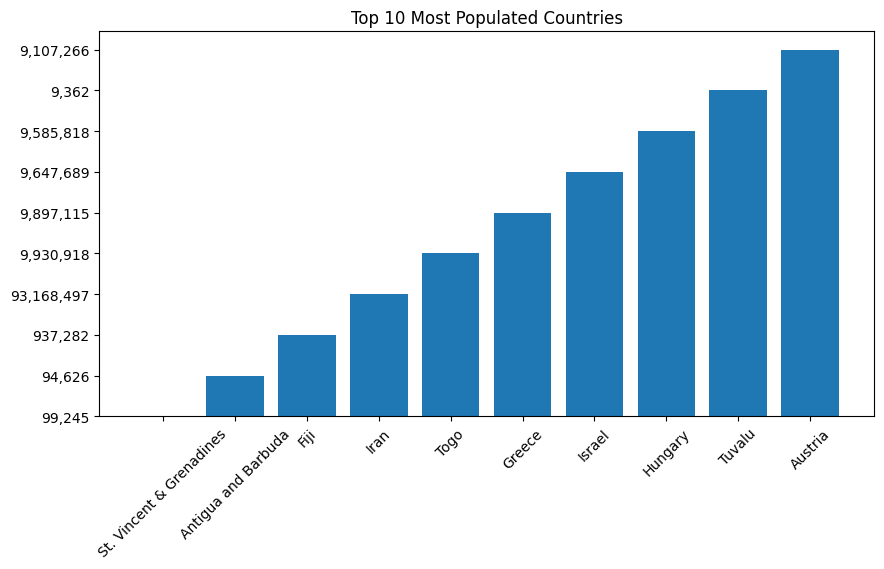

In [11]:
#Visualization
top10 = df_sorted.head(10)
plt.figure(figsize=(10,5))
plt.bar(top10["Country"], top10["Population"])
plt.xticks(rotation=45)
plt.title("Top 10 Most Populated Countries")
plt.show()

In [12]:
print(df.dtypes)

Country          object
Population       object
Yearly Change    object
Net Change       object
Density          object
World Share      object
dtype: object


In [13]:
if df["Population"].dtype == "object":
    df["Population"] = df["Population"].str.replace(",", "").astype(int)

In [14]:
if df["Density"].dtype == "object":
    df["Density"] = df["Density"].str.replace(",", "").astype(int)

if df["Net Change"].dtype == "object":
    df["Net Change"] = df["Net Change"].str.replace(",", "").astype(int)

In [15]:
df.head()

,Country,Population,Yearly Change,Net Change,Density,World Share
0,India,1476625576,0.87%,12760051,497,"2,973,190"
1,China,1412914089,-0.22%,-3182005,150,"9,388,211"
2,United States,349035494,0.51%,1759687,38,"9,147,420"
3,Indonesia,287886782,0.76%,2165546,159,"1,811,570"
4,Pakistan,259299791,1.6%,4080237,336,"770,880"


In [16]:
df.to_csv("population_clean.csv", index=False, encoding="utf-8")

In [17]:
from google.colab import files
files.download("population_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
df.isnull().sum()  #no missing values showing the dataset is clean now

,0
Country,0
Population,0
Yearly Change,0
Net Change,0
Density,0
World Share,0


In [21]:
df.duplicated().sum() #no duplicate rows

np.int64(0)